<a href="https://colab.research.google.com/github/Shashank-sketchAl/Machine-Learning-Training/blob/main/SMOTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import libraries and dataset (Load files to colab)

In [163]:
#from google.colab import files
#uploaded = files.upload()

In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Load the dataset and create the dataframe

In [165]:
df = pd.read_csv('diabetes.csv')

#Data Preprocessing

1) Checking the dataset for NaN values

In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [167]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


2) Imputing all the outliers values in the dataset

Imputing Glucose

In [168]:
(df['Glucose'] == 0).sum()

np.int64(5)

In [169]:
df['Glucose'].skew()

np.float64(0.17375350179188992)

In [170]:
df['Glucose'] = df['Glucose'].replace(0, df['Glucose'].mean())

Imputing BloodPressure

In [171]:
(df['BloodPressure']==0).sum()

np.int64(35)

In [172]:
(df['BloodPressure']).skew()

np.float64(-1.8436079833551302)

In [173]:
df['Glucose'] = df['Glucose'].replace(0, df['Glucose'].median())

Imputing SkinThickness

In [174]:
(df['SkinThickness']==0).sum()

np.int64(227)

In [175]:
df['SkinThickness'].skew()

np.float64(0.10937249648187608)

In [176]:
df['SkinThickness'] = df['SkinThickness'].replace(0,df['SkinThickness'].mean())

Imputing Insulin

In [177]:
(df['Insulin']==0).sum()

np.int64(374)

In [178]:
df['Insulin'].skew()

np.float64(2.272250858431574)

In [179]:
df['Insulin'] = df['Insulin'].replace(0,df['Insulin'].median())

Imputing BMI

In [180]:
(df['BMI'] == 0).sum()

np.int64(11)

In [181]:
df['BMI'].skew()

np.float64(-0.42898158845356543)

In [182]:
df['BMI'] = df['BMI'].replace(0,df['BMI'].mean())

Imputing DiabetesPedigreeFunction

In [183]:
(df['DiabetesPedigreeFunction']==0).sum()

np.int64(0)

Imputing Age

In [184]:
(df['Age']==0).sum()

np.int64(0)

In [185]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72,35.000000,30.5,33.6,0.627,50,1
1,1,85.0,66,29.000000,30.5,26.6,0.351,31,0
2,8,183.0,64,20.536458,30.5,23.3,0.672,32,1
3,1,89.0,66,23.000000,94.0,28.1,0.167,21,0
4,0,137.0,40,35.000000,168.0,43.1,2.288,33,1


#Data Visualization

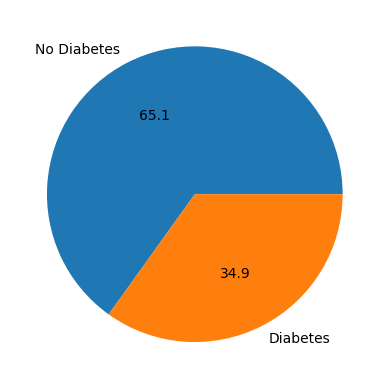

In [186]:
plt.pie(df['Outcome'].value_counts(), labels = ['No Diabetes', 'Diabetes'], autopct = '%.1f')

plt.show()

In [187]:
# 0 = Not Diabetic
# 1 = Diabetic

df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


#Train - Test Split


1) Selecting Input Features for ML Model

In [188]:
X= df.drop('Outcome',axis=1)
X.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72,35.000000,30.5,33.6,0.627,50
1,1,85.0,66,29.000000,30.5,26.6,0.351,31
2,8,183.0,64,20.536458,30.5,23.3,0.672,32
3,1,89.0,66,23.000000,94.0,28.1,0.167,21
4,0,137.0,40,35.000000,168.0,43.1,2.288,33


2) Selecting output for ML Model

In [189]:
y= df['Outcome']
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


Split Dataset into Train-Test

In [190]:
from sklearn.model_selection import train_test_split

X_train,X_test , y_train,  y_test = train_test_split(X,y,test_size=0.2,random_state=42)

4. Count the Values in Each Class in the Training Data (before SMOTE)


In [191]:
y_train.value_counts()

,count
Outcome,
0,401
1,213


#Feature Scaling

In [192]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

#SMOTE

Import SMOTE from sklearn and create the object for SMOTE

In [193]:
from imblearn.over_sampling import SMOTE

oversampling = SMOTE(sampling_strategy='auto',k_neighbors=5,random_state=42)


In [194]:
X_train, y_train =oversampling.fit_resample(X_train, y_train)

In [195]:
y_train.value_counts()

,count
Outcome,
0,401
1,401


#Traing the model

Import Random forest from sklearn

In [196]:
from sklearn.ensemble import RandomForestClassifier

Making an object for random forest

In [197]:
rf = RandomForestClassifier()

Train the random forest classifier model

In [198]:
rf.fit(X_train, y_train)

RandomForestClassifier()

Test the model prediction (X_prediction)

In [199]:
#Finding the Predicted Values

y_pred = rf.predict(X_test)

print(y_pred)

[0 0 0 0 1 1 0 1 1 1 0 1 0 0 0 1 0 0 1 1 0 0 0 0 1 1 0 0 0 0 1 1 1 1 1 1 1
 1 0 1 0 0 1 1 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0
 0 0 0 0 0 0 1 0 0 1 0 1 1 1 0 0 0 0 0 1 1 1 1 0 1 0 1 0 1 1 1 0 0 1 0 1 0
 0 0 1 0 1 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 0 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0
 0 1 0 0 1 0]


#Model evaluation

In [200]:
from sklearn.metrics import classification_report, accuracy_score

In [201]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:",acc)
print()

cr = classification_report(y_test, y_pred)
print("Classification Report:")
print (cr)

Accuracy: 0.7792207792207793

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.77      0.82        99
           1       0.66      0.80      0.72        55

    accuracy                           0.78       154
   macro avg       0.77      0.78      0.77       154
weighted avg       0.80      0.78      0.78       154



#Model Prediction

In [202]:
def user_input():
    preg = int(input("Enter the Number of Pregnancies: "))
    glu = float(input("Enter the Glucose: "))
    bp = int(input("Enter the Blood Pressure: "))
    st = float(input("Enter the Skin Thickness: "))
    ins = float(input("Enter the Blood Insulin: "))
    bmi = float(input("Enter the BMI: "))
    dpf = float(input("Enter the Diabetes Pedigree Function: "))
    age = int(input("Enter the Age: "))

    # Create a DataFrame with User Input
    user_data = pd.DataFrame([[preg, glu, bp, st, ins, bmi, dpf, age]], columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'])

    # Predict using the Decision Tree Model
    prediction = rf.predict(user_data)

    # Print the Prediction Result
    if prediction[0] == 0:
        print("Predicted Outcome: NOT Diabetes Likely.")
    elif prediction[0] == 1:
        print("Predicted Outcome: Diabetes Likely.")
    else:
        print("Invalid Prediction.")